# 02 — Banking Fraud Detection: Data Understanding (EDA)

La pregunta de negocio detrás de este proyecto se puede resumir en una frase: ¿qué transacciones son fraudulentas, y en qué umbral de decisión se minimiza el costo total — fraude no detectado versus fricción por falso positivo?

Este notebook cubre la fase de Data Understanding: nulos, outliers, cardinalidad y un chequeo de data leakage, todo sobre el dataset real [Credit Card Fraud Detection (ULB)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). Todavía no hay feature engineering ni modelado — eso empieza en el próximo notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

DATA_PATH = '../data/creditcard.csv'

## 1. Carga de datos

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Estructura y tipos

| Columna | Significado |
|---|---|
| `Time` | segundos transcurridos desde la primera transacción del dataset (~48 h de datos) |
| `V1`...`V28` | componentes de un PCA aplicado por el proveedor del dataset sobre las variables originales — anonimizadas, sin significado de negocio recuperable |
| `Amount` | monto de la transacción |
| `Class` | 1 = fraude, 0 = legítima |

In [3]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

## 3. Nulos

In [4]:
nulls = df.isnull().sum()
assert nulls.sum() == 0
print('Sin valores nulos en ninguna columna.')

Sin valores nulos en ninguna columna.


## 4. Duplicados: un detalle que cambia cómo hay que armar el split

In [5]:
n_dup = df.duplicated().sum()
dup_by_class = df.loc[df.duplicated(), 'Class'].value_counts()

print(f'Filas duplicadas exactas: {n_dup} ({n_dup / len(df) * 100:.2f}% del dataset)')
print(dup_by_class)

Filas duplicadas exactas: 1081 (0.38% del dataset)
Class
0    1062
1      19
Name: count, dtype: int64


Este es un dataset muy citado — el de ULB aparece en decenas de papers y cursos de fraude — así que no esperaba tropezarme con un problema de calidad de datos ahí. Pero apareció: 1.081 filas duplicadas exactas (todas las columnas iguales, incluyendo `Class`), de las cuales 1.062 son legítimas y 19 son fraude. Con solo 492 fraudes en total, esos 19 duplicados equivalen a casi 4% (3.9%) de la clase positiva. No es ruido que se pueda ignorar.

La razón por la que esto importa para el split y no solo para la limpieza: si la deduplicación se hiciera después de separar train y test — o no se hiciera — una fila y su copia exacta podrían terminar repartidas entre ambos conjuntos. El modelo vería en test una transacción idéntica a otra que ya memorizó en train. Es data leakage silencioso: infla la métrica de test sin que el modelo haya generalizado nada. Por eso la decisión para Data Preparation es deduplicar antes de cualquier split, no después.

## 5. Balance de clases, el problema de fondo

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


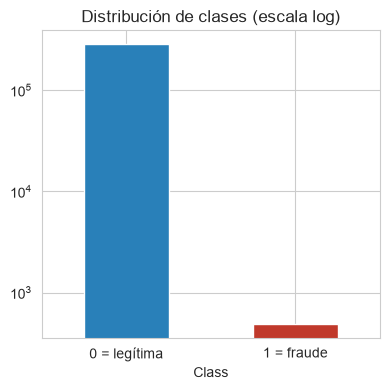

In [6]:
class_dist = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(class_dist)
print(class_pct.round(4))

fig, ax = plt.subplots(figsize=(4, 4))
class_dist.plot(kind='bar', ax=ax, color=['#2980b9', '#c0392b'])
ax.set_yscale('log')
ax.set_xticklabels(['0 = legítima', '1 = fraude'], rotation=0)
ax.set_title('Distribución de clases (escala log)')
plt.tight_layout()
plt.show()

Solo el 0.173% de las transacciones son fraude — 492 de 284.807. Es un desbalance extremo, bastante más severo que el desbalance moderado que vimos en project 01. Acá accuracy directamente no sirve: un modelo que nunca predijera fraude tendría 99.8% de accuracy y sería inútil en la práctica.

Esto condiciona todo el enfoque de modelado que viene después: la sección 5 de `03_modeling.ipynb` usa PR-AUC como métrica principal en lugar de accuracy, y en la fase de preparación y modelado se evalúan SMOTE, class weights e Isolation Forest como formas de lidiar con el desbalance.

## 6. `Time` — patrón horario del fraude

In [7]:
print('¿Time está ordenado de forma no decreciente?', df['Time'].is_monotonic_increasing)
print(f"Rango: {df['Time'].min()} a {df['Time'].max()} segundos (~{df['Time'].max() / 3600:.1f} horas)")

¿Time está ordenado de forma no decreciente? True
Rango: 0.0 a 172792.0 segundos (~48.0 horas)


El dataset viene ordenado cronológicamente de punta a punta y cubre ~48 horas continuas, es decir, dos días completos. Esto habilita un split train/test cronológico en la fase de preparación —entrenar sobre el primer período y evaluar sobre el segundo—, tal como se hizo en project 01. Es un split más representativo del uso real en producción que uno aleatorio, porque en producción el modelo siempre predice sobre datos que todavía no vio, nunca sobre el pasado.

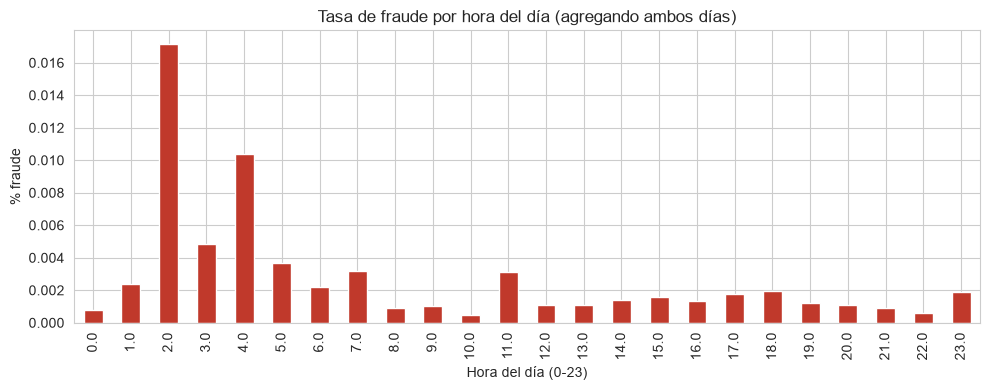

hour_of_day
2.0    0.017127
4.0    0.010412
3.0    0.004868
5.0    0.003679
7.0    0.003175
Name: Class, dtype: float64

In [8]:
df['hour_of_day'] = (df['Time'] % 86400) // 3600
rate_by_hour = df.groupby('hour_of_day')['Class'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
rate_by_hour.plot(kind='bar', ax=ax, color='#c0392b')
ax.set_title('Tasa de fraude por hora del día (agregando ambos días)')
ax.set_xlabel('Hora del día (0-23)')
ax.set_ylabel('% fraude')
plt.tight_layout()
plt.show()

rate_by_hour.sort_values(ascending=False).head(5)

La tasa de fraude sube visiblemente durante la madrugada —horas 2 y 4 de cada ciclo de 24h—, bien por encima del promedio general de ~0.17%. Es un hallazgo interesante, pero hay que tomarlo con pinzas: con solo dos días de datos no alcanza para confirmarlo como un patrón estable, y bien podría ser ruido de muestra chica en horas de bajo volumen de transacciones. Aun así, es una hipótesis de negocio razonable para justificar monitoreo reforzado en horario nocturno, y se retoma más adelante en el análisis descriptivo del dashboard.

## 7. `Amount` — distribución y outliers

In [9]:
print(df.groupby('Class')['Amount'].describe())
print()
print('Transacciones con Amount == 0:', (df['Amount'] == 0).sum())
print('Transacciones con Amount < 0:', (df['Amount'] < 0).sum())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87

Transacciones con Amount == 0: 1825
Transacciones con Amount < 0: 0


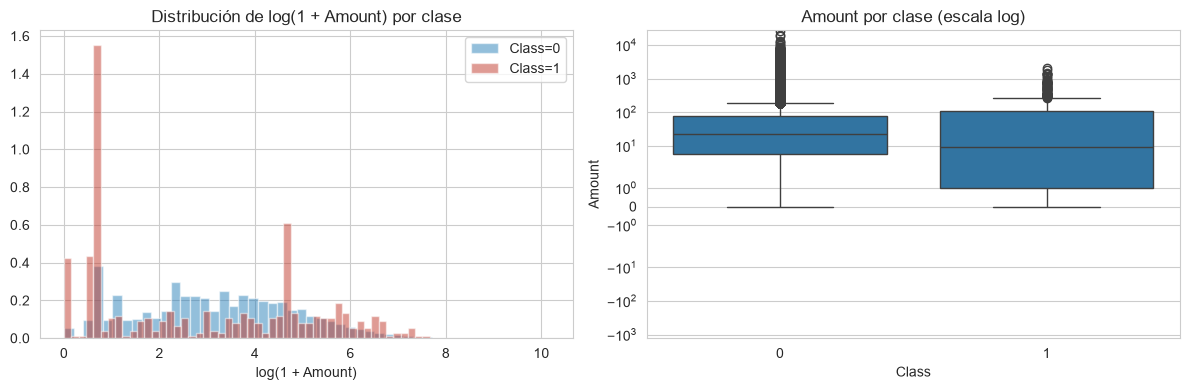

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, color in [(0, '#2980b9'), (1, '#c0392b')]:
    subset = df.loc[df['Class'] == cls, 'Amount']
    axes[0].hist(np.log1p(subset), bins=50, alpha=0.5, density=True, label=f'Class={cls}', color=color)
axes[0].set_title('Distribución de log(1 + Amount) por clase')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].legend()

sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1])
axes[1].set_yscale('symlog')
axes[1].set_title('Amount por clase (escala log)')

plt.tight_layout()
plt.show()

No hay montos negativos, eso ya lo descarta como problema. Sí hay 1.825 transacciones con `Amount = 0` (1.798 legítimas, 27 fraude), que probablemente correspondan a transacciones de verificación o autorización sin cargo real — es un patrón conocido en datos de tarjetas, no un error de captura.

La mediana de `Amount` en fraude (9.25) es más baja que en legítimas (22.00), lo cual tiene sentido si uno piensa en pruebas de tarjeta con montos chicos. Pero también existe la cola derecha de fraudes de montos altos, así que no hay un corte limpio por monto que por sí solo separe las clases.

## 8. Las componentes `V1`–`V28`: acá el outlier no es ruido

Estas 28 componentes vienen de un PCA que ya aplicó el proveedor del dataset, así que no representan ninguna variable de negocio directa — no hay forma de saber si `V17` es "monto", "ubicación" o una combinación de ambas. Antes de aplicar cualquier regla de recorte de outliers, como se hizo en el EDA de project 01, conviene verificar si esos valores extremos concentran la señal de fraude. Si es así, recortarlos sería tirar a la basura la variable más útil que tiene el dataset.

In [11]:
v_cols = [c for c in df.columns if c.startswith('V')]
print('Media de las 28 componentes (rango):', df[v_cols].mean().min(), 'a', df[v_cols].mean().max())
print('Std de las 28 componentes (rango):', df[v_cols].std().min(), 'a', df[v_cols].std().max())

corr_with_class = df[v_cols + ['Class']].corr()['Class'].drop('Class').sort_values()
print()
print('5 componentes más correlacionadas (negativamente) con fraude:')
print(corr_with_class.head(5))
print()
print('5 componentes más correlacionadas (positivamente) con fraude:')
print(corr_with_class.tail(5))

Media de las 28 componentes (rango): -2.4141892388190378e-15 a 4.866698941746315e-15
Std de las 28 componentes (rango): 0.3300832641602509 a 1.958695803857486



5 componentes más correlacionadas (negativamente) con fraude:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

5 componentes más correlacionadas (positivamente) con fraude:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


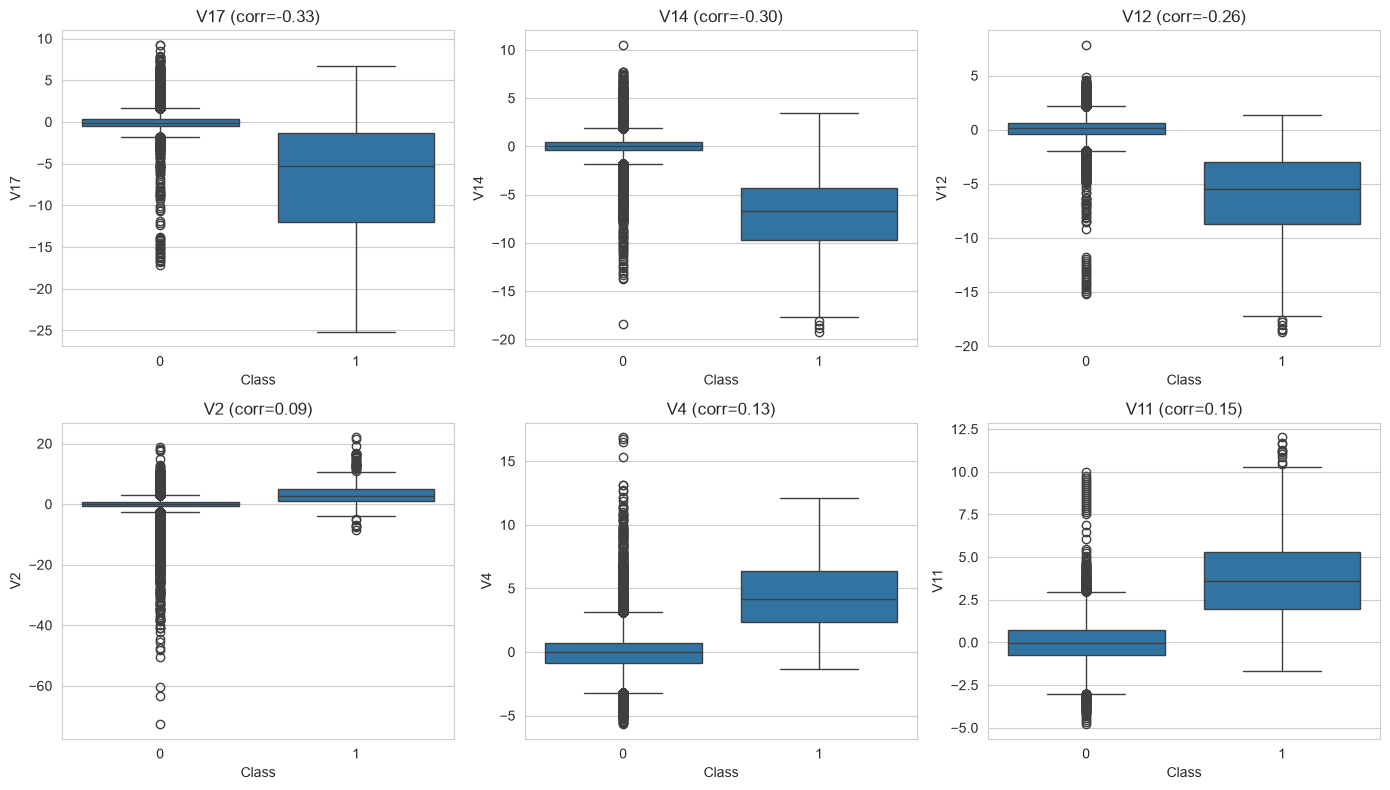

In [12]:
top_features = corr_with_class.head(3).index.tolist() + corr_with_class.tail(3).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, top_features):
    sns.boxplot(data=df, x='Class', y=col, ax=ax)
    ax.set_title(f'{col} (corr={corr_with_class[col]:.2f})')
plt.tight_layout()
plt.show()

Y efectivamente se confirma: en `V17`, `V14` y `V12` —las tres componentes más correlacionadas con la clase— el fraude se concentra justo en los valores que un chequeo automático de outliers (regla IQR, z-score) marcaría para recortar o directamente eliminar. Recortar ahí sería borrar la señal, no el ruido.

Decisión para Data Preparation: no se aplica recorte de outliers sobre `V1`–`V28`.

## 9. Chequeo de data leakage

`Time` es información disponible en el momento mismo de la transacción, no del futuro, así que usarla como feature no es leakage — y el patrón horario de la sección 6 sugiere que sí aporta señal real.

`Amount` está en la misma situación: disponible al momento de la transacción, sin leakage.

`V1`–`V28` es el caso más incómodo de los tres. Ya vienen anonimizadas por PCA por el proveedor del dataset, y no hay forma de verificar si alguna combinación original incluía información posterior a la transacción (por ejemplo, si el banco ya la había marcado). Lo documento como limitación de interpretabilidad, no como leakage confirmado, porque no hay evidencia concreta de que exista. Pero tampoco se puede descartar del todo — a diferencia de project 01, donde el leakage (`avg_aht` vs `std_pass`) sí fue verificable de forma directa.

## 10. Balance de esta etapa

Sin nulos, eso fue lo fácil. Lo que sí apareció: 1.081 duplicados exactos, 19 de ellos fraude, y tienen que eliminarse antes de separar train/test — si no, se filtra información entre ambos conjuntos por la puerta de atrás.

El desbalance es extremo: 0.173% de fraude. Esto define el proyecto entero. Accuracy queda descartada como métrica, y la fase de preparación/modelado tiene que evaluar SMOTE, class weights e Isolation Forest para lidiar con esto.

`Time` habilita un split cronológico, porque el dataset ya viene ordenado y cubre ~48 horas — más representativo del uso real que un split aleatorio, igual que en project 01.

Hay un patrón horario que vale la pena seguir de cerca: la tasa de fraude sube notablemente de madrugada. Es una hipótesis de negocio para explorar en el dashboard, con la salvedad de que son solo 2 días de datos y podría no sostenerse con más volumen.

Los outliers en `V1`–`V28` no se recortan. Las componentes más correlacionadas con fraude (`V17`, `V14`, `V12`) tienen la señal concentrada justo en los valores extremos, así que cualquier regla automática de recorte habría sido contraproducente.

Y queda una limitación real de interpretabilidad: las componentes PCA no tienen significado de negocio recuperable. El modelo va a ser predictivo, pero no va a poder explicar qué variable original dispara el riesgo — solo cuánto aporta cada componente. Eso se aborda con SHAP más adelante, en el notebook de modelado.

Siguiente paso: `02_data_preparation.ipynb`, donde toca deduplicar, escalar `Time` y `Amount`, decidir la estrategia de split y dejar el dataset listo para comparar técnicas de manejo de desbalance extremo.